In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
df = pd.read_csv("df.csv")
df = df.drop(columns=['Unnamed: 0'])
df["Data_hora"] = pd.to_datetime(df["Data_hora"])
df["Data"] = df["Data_hora"].dt.date #criação da coluna data separada
df["Hora"] = df["Data_hora"].dt.hour #criação da coluna hora separada

### Contagem das médias diárias válidas seguindo a orientação do guia técnico
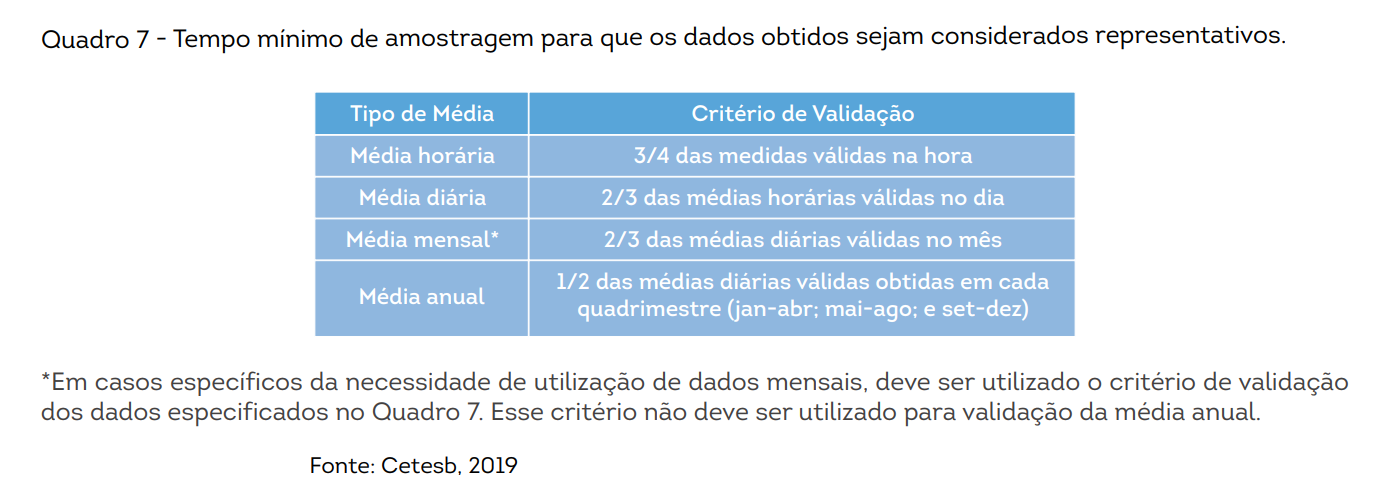

In [28]:
media_horaria = (
    df.groupby(["Estado","Estacao", "Poluente", "Data", "Hora"])["Valor"]
    .mean()
    .reset_index(name="media_horaria")
)

In [29]:
# A média diária só é considerada válida se houver pelo menos 2/3 das médias horárias do dia. Sendo assim, precisamos de 16 ou mais horas
# válidas para que a média do dia seja representativa

contagem_horas_validas = (
    media_horaria.groupby(["Estado","Estacao", "Poluente", "Data"])["media_horaria"]
    .count()
    .reset_index(name="horas_validas")
)


In [30]:
# criação da coluna dia_valido para contabilização

contagem_horas_validas["dia_valido"] = contagem_horas_validas["horas_validas"] >= 16

print(contagem_horas_validas)

       Estado           Estacao Poluente        Data  horas_validas  \
0          BA  Av. ACM - DETRAN     MP10  2015-01-01             24   
1          BA  Av. ACM - DETRAN     MP10  2015-01-02             24   
2          BA  Av. ACM - DETRAN     MP10  2015-01-03             24   
3          BA  Av. ACM - DETRAN     MP10  2015-01-04             24   
4          BA  Av. ACM - DETRAN     MP10  2015-01-05             24   
...       ...               ...      ...         ...            ...   
591536     SP           Taubaté    MP2.5  2022-12-28             24   
591537     SP           Taubaté    MP2.5  2022-12-29             24   
591538     SP           Taubaté    MP2.5  2022-12-30             11   
591539     SP           Taubaté    MP2.5  2022-12-31             17   
591540     SP           Taubaté    MP2.5  2023-01-01              1   

        dia_valido  
0             True  
1             True  
2             True  
3             True  
4             True  
...            ...  


In [31]:
# Ordenando as estações por dias válidos

Estacoes_Por_Dias_Validos = (
    contagem_horas_validas
    .groupby(["Estado","Estacao", "Poluente"])["dia_valido"]
    .sum()
    .reset_index(name="dias_validos")
    .sort_values("dias_validos", ascending=False)
)

In [32]:
Estacoes_Por_Dias_Validos

,Estado,Estacao,Poluente,dias_validos
324,SP,Araçatuba,MP10,2882
413,SP,São Bernardo do Campo - Paulicéia,MP10,2851
341,SP,Cubatão - Vale do Mogi,MP10,2847
424,SP,Tatuí,MP10,2843
323,SP,Araraquara,MP10,2838
...,...,...,...,...
261,RJ,RJ - São Cristovão,MP10,0
263,RJ,RJ - UERJ,MP10,0
339,SP,Cordeirópolis - Módolo,MP10,0
338,SP,Cordeiropolis - Modolo,MP10,0


In [33]:
contagem_horas_validas["Data"] = pd.to_datetime(contagem_horas_validas["Data"])

def maior_sequencia(grupo):
    grupo = grupo.sort_values("Data")
    # cria um "id de grupo" toda vez que quebra a sequência
    grupo["consec"] = (grupo["Data"].diff().dt.days.ne(1)).cumsum()
    # filtra só dias válidos e conta o tamanho das sequências
    max_seq = grupo[grupo["dia_valido"]].groupby("consec").size().max()
    return pd.Series({"maior_seq_valida": max_seq})

sequencias = (
    contagem_horas_validas
    .groupby(["Estado","Estacao", "Poluente"])
    .apply(maior_sequencia)
    .reset_index()
)

print(sequencias)

    Estado             Estacao Poluente  maior_seq_valida
0       BA    Av. ACM - DETRAN     MP10             243.0
1       BA     Av. Barros Reis     MP10             243.0
2       BA             Botelho     MP10             238.0
3       BA        Campo Grande     MP10             238.0
4       BA           Concórdia     MP10             993.0
..     ...                 ...      ...               ...
422     SP  São Sebastião - SP    MP2.5             175.0
423     SP     Taboão da Serra     MP10             780.0
424     SP               Tatuí     MP10             719.0
425     SP             Taubaté     MP10            1244.0
426     SP             Taubaté    MP2.5             786.0

[427 rows x 4 columns]


C:\Users\lucas\AppData\Local\Temp\ipykernel_35348\1300862893.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(maior_sequencia)


In [34]:
# --- 1) Total de dias válidos por estação/poluente ---
total_dias_validos = (
    contagem_horas_validas
    .groupby(["Estado","Estacao", "Poluente"])["dia_valido"]
    .sum()
    .reset_index(name="total_dias_validos")
)

# --- 2) Maior sequência de dias válidos consecutivos ---
contagem_horas_validas["Data"] = pd.to_datetime(contagem_horas_validas["Data"])

def maior_sequencia(grupo):
    grupo = grupo.sort_values("Data")
    # cria grupos sempre que a diferença de dias não é 1
    grupo["consec"] = (grupo["Data"].diff().dt.days.ne(1)).cumsum()
    # filtra só dias válidos e pega o tamanho máximo da sequência
    max_seq = grupo[grupo["dia_valido"]].groupby("consec").size().max()
    return pd.Series({"maior_seq_valida": max_seq})

sequencias = (
    contagem_horas_validas
    .groupby(["Estado","Estacao", "Poluente"])
    .apply(maior_sequencia)
    .reset_index()
)

# --- 3) Combinar em um único ranking ---
ranking_estacoes = (
    total_dias_validos
    .merge(sequencias, on=["Estado","Estacao", "Poluente"])
    .sort_values(["total_dias_validos", "maior_seq_valida"], ascending=False)
)

print(ranking_estacoes)

    Estado                            Estacao Poluente  total_dias_validos  \
324     SP                          Araçatuba     MP10                2882   
413     SP  São Bernardo do Campo - Paulicéia     MP10                2851   
341     SP             Cubatão - Vale do Mogi     MP10                2847   
424     SP                              Tatuí     MP10                2843   
342     SP              Cubatão - Vila Parisi     MP10                2838   
..     ...                                ...      ...                 ...   
391     SP              Piracicaba - Algodoal     MP10                   0   
395     SP    Ribeirão Preto - Campos Elíseos     MP10                   0   
400     SP      Santa Gertrudes - Jd. Luciana     MP10                   0   
404     SP                        Santo Amaro    MP2.5                   0   
406     SP              Santo André - Capuava    MP2.5                   0   

     maior_seq_valida  
324            1013.0  
413            

C:\Users\lucas\AppData\Local\Temp\ipykernel_35348\4253306438.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(maior_sequencia)


In [ ]:
#

In [43]:
MP10_Estacoes = ranking_estacoes[ranking_estacoes['Poluente'] == 'MP10']
MP25_Estacoes = ranking_estacoes[ranking_estacoes['Poluente'] == 'MP2.5']

In [44]:
MP10_Estacoes_1ano_val = MP10_Estacoes[MP10_Estacoes['maior_seq_valida'] >= 365]
MP25_Estacoes_1ano_val = MP25_Estacoes[MP25_Estacoes['maior_seq_valida'] >= 365]

In [35]:
Estacoes_1ano_val = ranking_estacoes[ranking_estacoes['maior_seq_valida'] >= 365]

In [37]:
Estacoes_1ano_val['Estado'].value_counts()

Estado
SP    66
MG    45
RJ    38
ES    16
BA     4
RS     2
PR     1
Name: count, dtype: int64

In [45]:
MP10_Estacoes_1ano_val['Estado'].value_counts()

Estado
SP    48
RJ    36
MG    29
ES    12
BA     4
RS     2
PR     1
Name: count, dtype: int64

In [46]:
MP25_Estacoes_1ano_val['Estado'].value_counts()

Estado
SP    18
MG    16
ES     4
RJ     2
Name: count, dtype: int64

Decisão por usar apenas os estados de SP, MG, ES e RJ

In [53]:
MP10_Estacoes_1ano_val = MP10_Estacoes_1ano_val[MP10_Estacoes_1ano_val['Estado'].isin(['SP','MG','ES','RJ'])]

In [59]:
lista_estacoes_25 = list(MP25_Estacoes_1ano_val['Estacao'].unique())

In [60]:
lista_estacoes_10 = list(MP10_Estacoes_1ano_val['Estacao'].unique())

In [61]:
estacoes_selecionadas = lista_estacoes_10 
for estacao in lista_estacoes_25:
    if estacao not in estacoes_selecionadas:
        estacoes_selecionadas.append(estacao)

In [62]:
estacoes_selecionadas

['Araçatuba',
 'São Bernardo do Campo - Paulicéia',
 'Cubatão - Vale do Mogi',
 'Tatuí',
 'Cubatão - Vila Parisi',
 'Araraquara',
 'Catanduva',
 'Santos - Ponta da Praia',
 'São José do Rio Preto',
 'Jundiaí',
 'Paulínia',
 'Marg. Tietê - Pte dos Remédios',
 'Marília',
 'Cerqueira César',
 'Osasco',
 'Santa Gertrudes',
 'Taboão da Serra',
 'Santo André - Capuava',
 'Congonhas',
 'Jaú',
 'Panorama',
 'Cidade Nobre',
 'Sorocaba',
 'Campinas - Centro',
 'Major Lage',
 'NI - Jardim Guandu',
 'Centro - Av. do Contorno',
 'Nossa Senhora do Ó',
 'Centro Administrativo',
 'São José dos Campos',
 'Bairro Piratininga',
 'Sementinha',
 'Bauru',
 'Itb - Porto das Caixas',
 'Carapicuíba',
 'São Caetano do Sul',
 'Itg - Coroa Grande',
 'Itb - Sambaetiba',
 'Itaim Paulista',
 'Parque Dom Pedro II',
 'Capão Redondo',
 'Interlagos',
 'Anchieta Centro',
 'Bairro Petrovale',
 'Itt - Campo Alegre',
 'DC - Pilar',
 'DC - Campos Elíseos',
 'Sérgio Ulhoa',
 'Diadema',
 'Presidente Prudente',
 'Taubaté',
 'Cu

In [63]:
df_estacoes_selecionadas = df[df['Estacao'].isin(estacoes_selecionadas)]

In [64]:
df_estacoes_selecionadas.to_csv('df_est_sel.csv')